# Unified Engineering<br> 16.002 Signals and Systems<br> Solving Various ODEs
## Jonathan P. How <br> Massachusetts Institute of Technology<br> jhow@mit.edu


**Contents:** <pre> 
[Solving Analytically](#s1)  
[Solving Numerically](#s2)  
 </pre>

In [11]:
%reload_ext autoreload
%autoreload 2

In [12]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [13]:
colors = bm.get_colors()
j = complex(0,1)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp

import sympy as sym
from sympy import symbols, Eq, Function, dsolve
from sympy import exp, plot, sin, cos, printing, init_printing, simplify
t = sym.symbols('t')
y = sym.symbols('y', cls=sym.Function)(t)

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [14]:
#https://github.com/mkrphys/ipython-tikzmagic/blob/master/tikzmagic_test.ipynb
#%pip install git+https://github.com/mkrphys/ipython-tikzmagic.git
%load_ext tikzmagic

The tikzmagic extension is already loaded. To reload it, use:
  %reload_ext tikzmagic


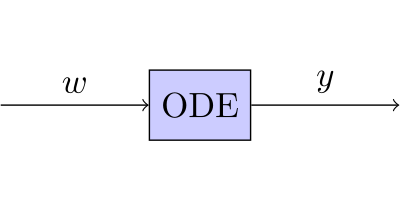

In [15]:
%%tikz -s 400,200 -sc 0.5 -f svg
\tikzstyle{int}=[node distance=1.5cm,auto,>=latex',draw, fill=blue!20, minimum size=2em]
\tikzstyle{init} = [pin edge={to-,thin,black}]
\usetikzlibrary {arrows}
\node [int] (a) {ODE};
\node (b) [left of=a,node distance=2cm, coordinate] {a};
\node [coordinate] (end) [right of=a, node distance=2cm]{};
\path[->] (b) edge node[above] {$w$} (a);
\draw[->] (a) edge node[above] {$y$} (end) ;


In [29]:
def Solve_ODE(A = [1,1,1], w = 0, Y0 = [0,0]):
    '''Solve a second-order ODE with given coefficients and initial conditions.
    A is a list of coefficients [a2, a1, a0] for the ODE: a2*y'' + a1*y' + a0*y = w(t)
    w is the input function (can be a constant, a function of t, or a symbolic expression)
    Y0 is a list of initial conditions [y(0), y'(0)]
    Returns a function that evaluates the solution at given time points.
    '''
    g0 = sym.symbols('g', cls=sym.Function)
    if len(A) == 3:
        g0 = A[0]*y.diff(t,t) + A[1]*y.diff(t) + A[2]*y - w 
        sol_0 = sym.dsolve(g0, ics={y.subs(t,0): Y0[0], sym.diff(y, t).subs(t,0): Y0[1]})        
    else:
        g0 = A[0]*y.diff(t) + A[1]*y - w 
        sol_0 = sym.dsolve(g0, ics={y.subs(t,0): Y0[0]})
    fun_0 = sym.lambdify([t],sol_0.rhs) 
    return fun_0

we = 3*exp(-3*t) # exponential input
phi = 0.0 # phase shift for sinusoid input
wc = 3*cos(3*t + phi) # sinusoid input

## <a name="s1" style="color:blue">Solving Analytically </a>

## First Order

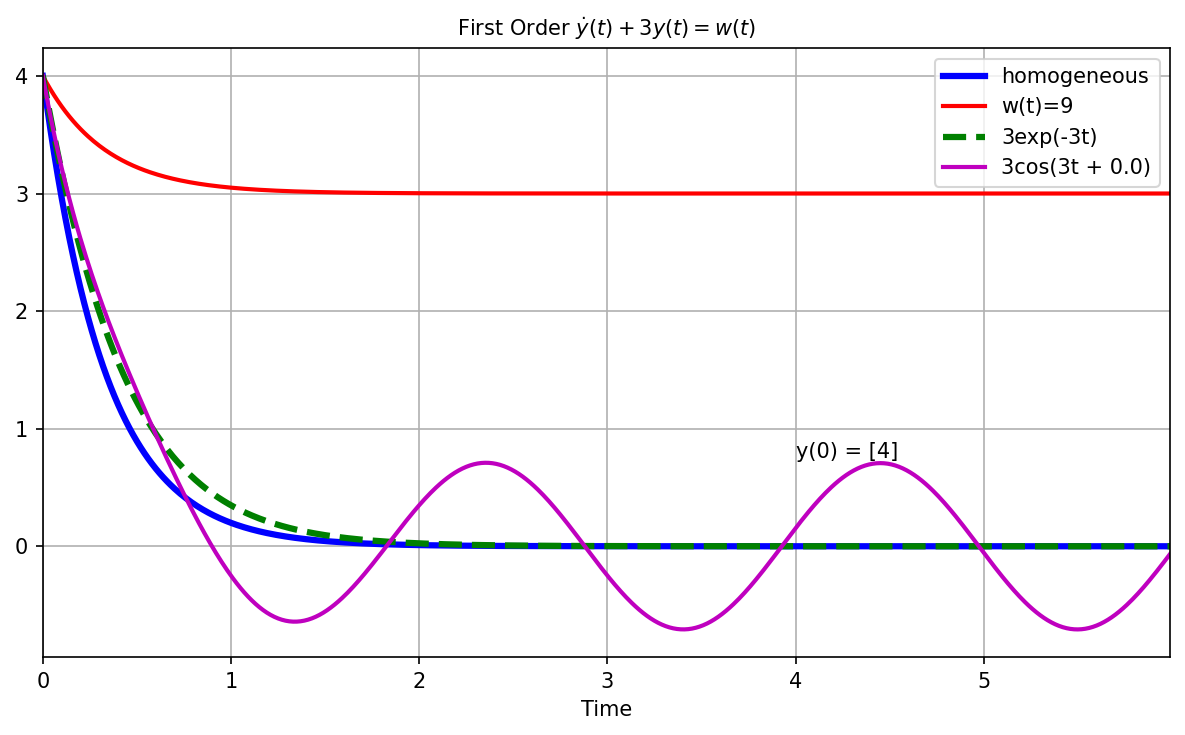

In [17]:
Y0 = [4] # IC
A = [1, 3] #ODE coefficients for first order system
fun_0 = Solve_ODE(A=A,w=0,Y0=Y0)
fun_1 = Solve_ODE(A=A,w=9,Y0=Y0)
fun_2 = Solve_ODE(A=A,w=we,Y0=Y0)
fun_3 = Solve_ODE(A=A,w=wc,Y0=Y0)

tt = np.arange(0, 6, 0.01)
fig = plt.figure(1,figsize=(8,5))
ax = fig.add_subplot()
ax.plot(tt,fun_0(tt),'b-',label='homogeneous',lw=3)
ax.plot(tt,fun_1(tt),'r-',label='w(t)=9')
ax.plot(tt,fun_2(tt),'g--',label='3exp(-3t)',lw=3)
ax.plot(tt,fun_3(tt),'m',label=f'3cos(3t + {phi:3.2})')
ax.set_xlabel('Time')
ax.text(4,.75,'y(0) = '+str(Y0))
plt.legend()
plt.title('First Order $\dot y(t) + 3y(t) = w(t)$')
plt.savefig('figs/first_order.png', dpi=300)
plt.show()

## Second Order 

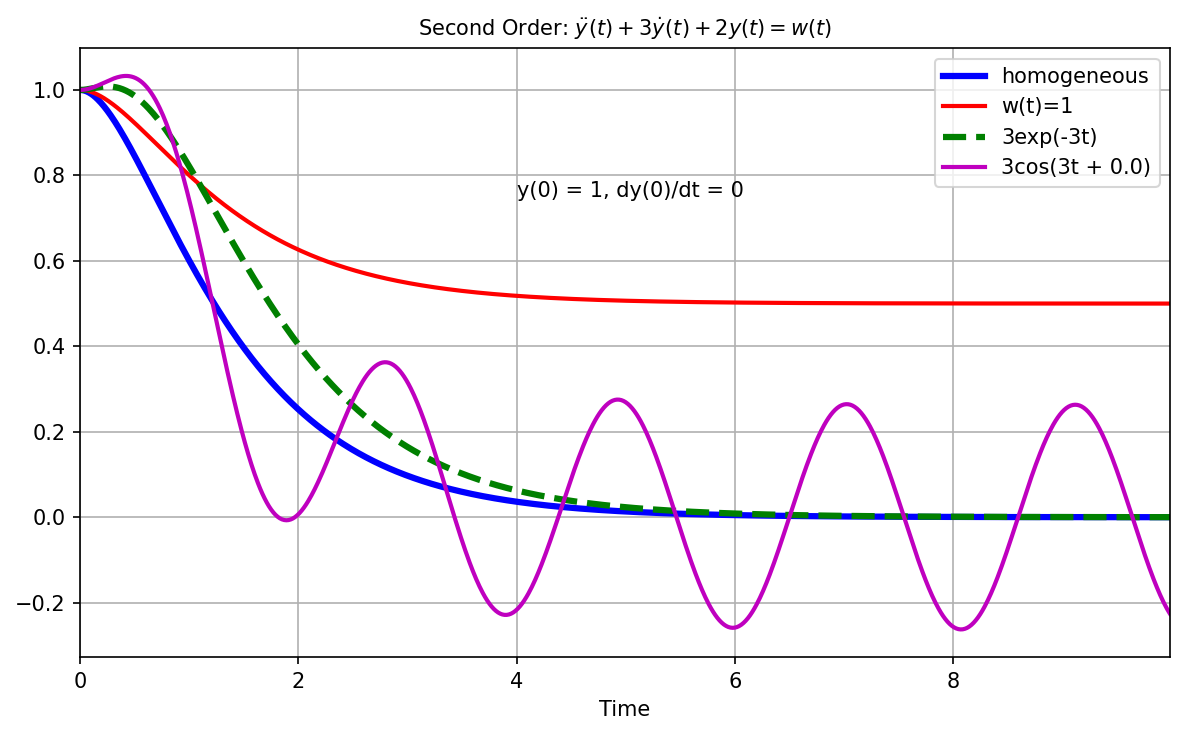

In [18]:
Y0 = [1, 0] #IC
A = [1, 3, 2] #ODE coefficients for second order system

fun_0 = Solve_ODE(A=A,w=0,Y0=Y0)
fun_1 = Solve_ODE(A=A,w=1,Y0=Y0)
fun_2 = Solve_ODE(A=A,w=we,Y0=Y0)
fun_3 = Solve_ODE(A=A,w=wc,Y0=Y0)

tt = np.arange(0, 10, 0.01)
fig = plt.figure(1,figsize=(8,5))
ax = fig.add_subplot()
ax.plot(tt,fun_0(tt),'b-',label='homogeneous',lw=3)
ax.plot(tt,fun_1(tt),'r-',label='w(t)=1')
ax.plot(tt,fun_2(tt),'g--',label='3exp(-3t)',lw=3)
ax.plot(tt,fun_3(tt),'m',label=f'3cos(3t + {phi:3.2})')
ax.text(4,.75,'y(0) = '+str(Y0[0])+', dy(0)/dt = '+str(Y0[1]))
ax.set_xlabel('Time')
plt.legend()
plt.title('Second Order: $\ddot y(t) + 3\dot y(t) + 2y(t) = w(t)$')
plt.savefig('figs/second_order.png', dpi=300)
plt.show()

## Second Order - Complex

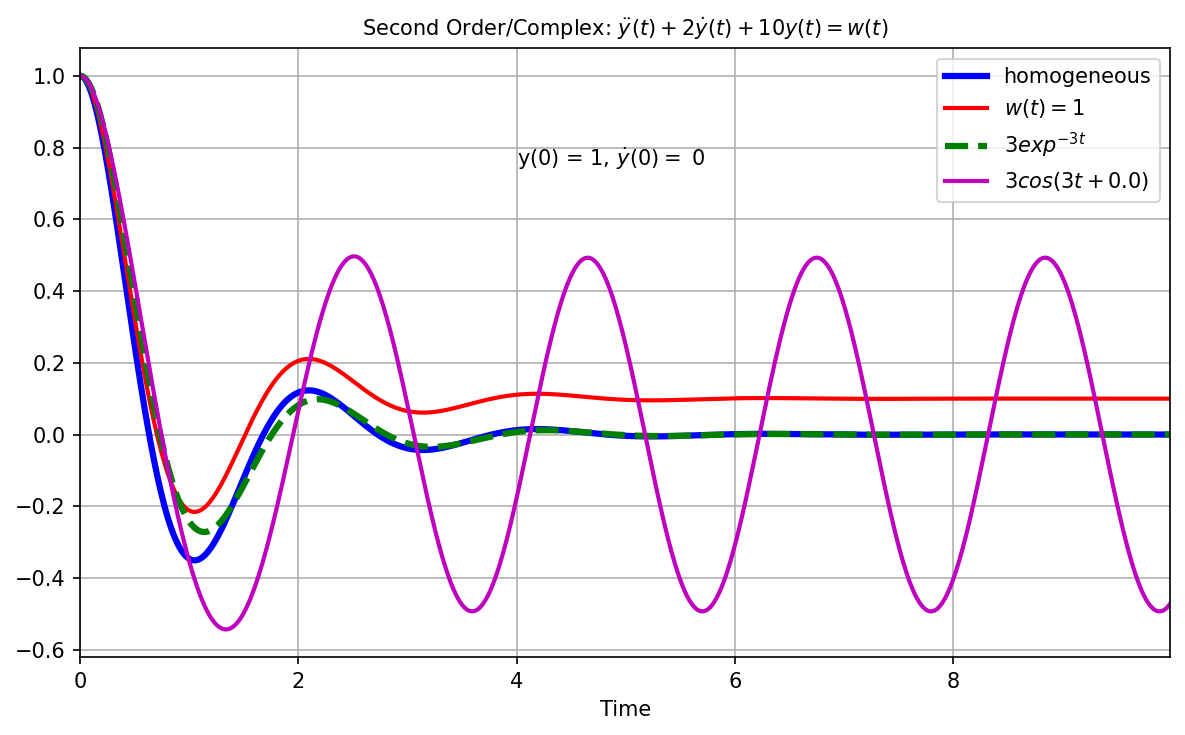

In [47]:
Y0 = [1, 0] # IC
A = [1, 2, 10] # ODE coefficients for second order system
fun_0 = Solve_ODE(A=A,w=0,Y0=Y0)
fun_1 = Solve_ODE(A=A,w=1,Y0=Y0)
fun_2 = Solve_ODE(A=A,w=we,Y0=Y0)
fun_3 = Solve_ODE(A=A,w=wc,Y0=Y0)

tt = np.arange(0, 10, 0.01)
fig = plt.figure(1,figsize=(8,5))
ax = fig.add_subplot()
ax.plot(tt,fun_0(tt),'b-',label='homogeneous',lw=3)
ax.plot(tt,fun_1(tt),'r-',label=r'$w(t)=1$')
ax.plot(tt,fun_2(tt),'g--',label=r'$3exp^{-3t}$',lw=3)
ax.plot(tt,fun_3(tt),'m',label=r'$3cos(3t + ' + str(phi) + r')$')
ax.text(4,.75,'y(0) = '+str(Y0[0])+r', $\dot y(0) =$ '+str(Y0[1]))
ax.set_xlabel('Time')
plt.legend()
a2_str = f"{A[0]:.0f}" if A[0] != 1 else ""
plt.title(
    rf'Second Order/Complex: ${a2_str}\ddot y(t) + {A[1]:.0f}\dot y(t) + {A[2]:.0f}y(t) = w(t)$'
)
plt.savefig('figs/second_order_complex.png', dpi=300)
plt.show()

## Second Order -- Complex Poles

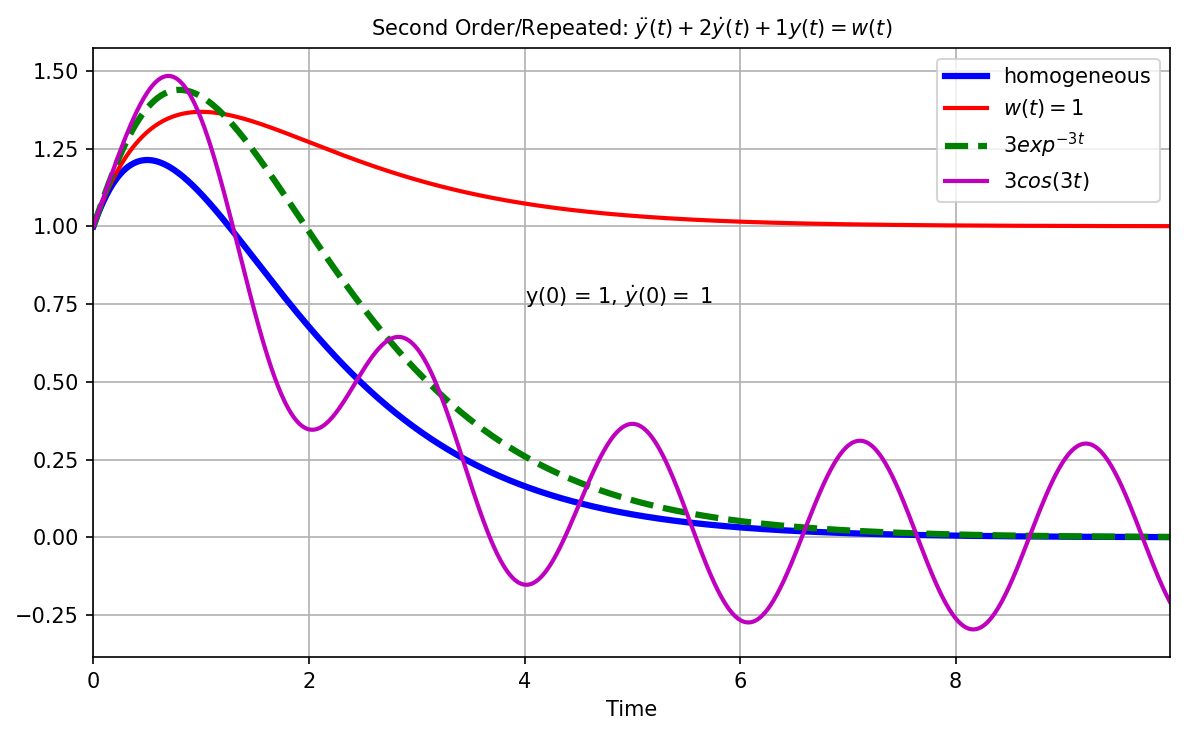

In [36]:
Y0 = [1, 1] # IC
A = [1, 2, 1] # ODE coefficients for second order system
fun_0 = Solve_ODE(A=A,w=0,Y0=Y0)
fun_1 = Solve_ODE(A=A,w=1,Y0=Y0)
fun_2 = Solve_ODE(A=A,w=we,Y0=Y0)
fun_3 = Solve_ODE(A=A,w=wc,Y0=Y0)

tt = np.arange(0, 10, 0.01)
fig = plt.figure(1,figsize=(8,5))
ax = fig.add_subplot()
ax.plot(tt,fun_0(tt),'b-',label='homogeneous',lw=3)
ax.plot(tt,fun_1(tt),'r-',label=r'$w(t)=1$')
ax.plot(tt,fun_2(tt),'g--',label=r'$3exp^{-3t}$',lw=3)
ax.plot(tt,fun_3(tt),'m',label=r'$3cos(3t)$')
ax.text(4,.75,'y(0) = '+str(Y0[0])+r', $\dot y(0) =$ '+str(Y0[1]))
ax.set_xlabel('Time')
plt.legend()
plt.title('Second Order/Repeated: $\ddot y(t) + 2\dot y(t) + 1y(t) = w(t)$')
plt.savefig('figs/second_order_repeated.png', dpi=300)
plt.show()

## Advanced Inputs

In [26]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

Y0 = [1, 0] # Initial conditions
A = [1, 3, 2] #ODE coeffs 

In [27]:
# Impulse response
g0 = A[0]*y.diff(t,t) + A[1]*y.diff(t) + A[2]*y - sym.DiracDelta(t)
sym.dsolve(g0, ics={y.subs(t,0): 0, sym.diff(y, t).subs(t,0): 0})

Eq(y(t), ((1/2 - Heaviside(t))*exp(-t) + Heaviside(t) - 1/2)*exp(-t))

In [28]:
# Step response
g1 = A[0]*y.diff(t,t) + A[1]*y.diff(t) + A[2]*y - sym.Heaviside(t)
sym.dsolve(g1, ics={y.subs(t,0): 0, sym.diff(y, t).subs(t,0): 0})

Eq(y(t), Heaviside(t)/2 - exp(-t)*Heaviside(t) + exp(-2*t)*Heaviside(t)/2)

## <a name="s2" style="color:blue">Solve Numerically </a>


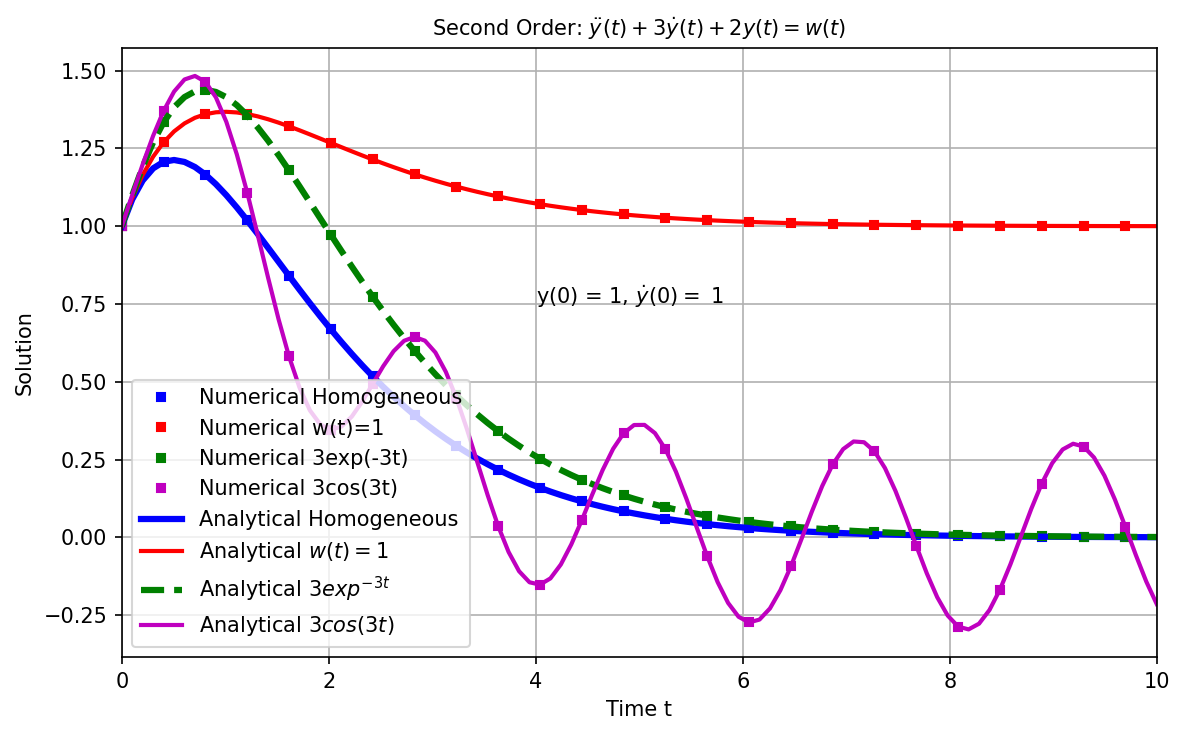

In [37]:
W0 = lambda t: 0
W1 = lambda t: 1
Wc = lambda t: 3*cos(3*t)
We = lambda t: 3*exp(-3*t)

def odes(t, Y, W): # second-order ODE written as a system of first-order ODEs
    y, v = Y
    dvdt = W(t) - A[1]/A[0] * v - A[2]/A[0]*y
    return [v, dvdt]

t_span = [0, 10] # Time span
t_eval = np.linspace(t_span[0], t_span[1], 100) # Time points where the solution is computed

# Numerically solve the ODE
solution_0 = solve_ivp(odes, t_span, Y0, t_eval=t_eval, args={W0})
solution_1 = solve_ivp(odes, t_span, Y0, t_eval=t_eval, args={W1})
solution_e = solve_ivp(odes, t_span, Y0, t_eval=t_eval, args={We})
solution_c = solve_ivp(odes, t_span, Y0, t_eval=t_eval, args={Wc})

# Analytically solve the ODE
fun_0 = Solve_ODE(A=A,w=0,Y0=Y0)
fun_1 = Solve_ODE(A=A,w=1,Y0=Y0)
fun_2 = Solve_ODE(A=A,w=we,Y0=Y0)
fun_3 = Solve_ODE(A=A,w=wc,Y0=Y0)

# plot to compare numerical and analytical solutions
fig = plt.figure(figsize=(8, 5)) # Plot the results
ax = fig.add_subplot()
ax.plot(solution_0.t, solution_0.y[0], 'bs', label='Numerical Homogeneous', ms=4, markevery=4)
ax.plot(solution_1.t, solution_1.y[0], 'rs', label='Numerical w(t)=1', ms=4, markevery=4)
ax.plot(solution_e.t, solution_e.y[0], 'gs', label='Numerical 3exp(-3t)', ms=4, markevery=4)
ax.plot(solution_c.t, solution_c.y[0], 'ms', label='Numerical 3cos(3t)', ms=4, markevery=4)
ax.plot(t_eval,fun_0(t_eval),'b-',label='Analytical Homogeneous',lw=3)
ax.plot(t_eval,fun_1(t_eval),'r-',label=r'Analytical $w(t)=1$')
ax.plot(t_eval,fun_2(t_eval),'g--',label=r'Analytical $3exp^{-3t}$',lw=3)
ax.plot(t_eval,fun_3(t_eval),'m',label=r'Analytical $3cos(3t)$')
ax.text(4,.75,'y(0) = '+str(Y0[0])+r', $\dot y(0) =$ '+str(Y0[1]))
ax.set_xlabel('Time t')
ax.set_ylabel('Solution')
ax.set_title('Solution of the Second-Order ODE')
ax.grid(True)

ax.legend()
plt.title('Second Order: $\ddot y(t) + 3\dot y(t) + 2y(t) = w(t)$')
plt.savefig('figs/second_order_2.png', dpi=300)
plt.show()